## Credit Risk clustering exercise (German Credit - 'credit-g' from OpenML)


In this exercise you will  understand the complexity of clustering real data, work with multiple dimensions/features, finetune your model, and attempt to interpret the results

In [ ]:
# - Histograms of selected numeric features
# - KMeans with elbow method (incl. kneedle-like distance-to-line heuristic)
# - Hierarchical clustering (Agglomerative)
# - PCA visualization (2D)
# - Cluster profiling: numeric means and categorical proportions
# - Silhouette score (sanity check)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
RANDOM_STATE = 42

# 1) Load dataset (German Credit from OpenML)
#    - 'class' is the target (good/bad). We'll use all other columns for unsupervised clustering.
data = fetch_openml(name="credit-g", version=1, as_frame=True)
df = data.frame.copy()

In [ ]:
df.columns

In [ ]:
df.dtypes

In [ ]:
# Separate features and target
target_col = "class"
X_df = df.drop(columns=[target_col])
y = df[target_col]  # not used for clustering, but useful for optional validation later

In [ ]:
# Identify numeric vs categorical features
numeric_features = X_df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_df.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

In [ ]:
# 2) Plot histograms of selected numeric features in a grid (up to 6)
hist_features = numeric_features[:6] if len(numeric_features) >= 6 else numeric_features

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for i, col in enumerate(hist_features):
    axes[i].hist(X_df[col], bins=30, color='#4C78A8', edgecolor='white')
    axes[i].set_title(f"Histogram: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
# Hide any unused subplots
for j in range(len(hist_features), 6):
    axes[j].axis("off")
fig.suptitle("German Credit – Histograms of Selected Numeric Features", fontsize=14)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Other things you could do: log transform skewed features, or reduce dimensionality, specially categorical variables

In [ ]:
# 3) Preprocess:
# - Standardize numeric features (important for Euclidean distance in KMeans/Ward)
# - One-hot encode categorical features (dense output for PCA)
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

X_transformed = preprocess.fit_transform(X_df)

In [ ]:
# For later profiling, get the encoded categorical column names
oh: OneHotEncoder = preprocess.named_transformers_["cat"]
cat_feature_names = []
if len(categorical_features) > 0:
    cat_feature_names = oh.get_feature_names_out(categorical_features).tolist()

num_feature_names = numeric_features
transformed_feature_names = num_feature_names + cat_feature_names

In [ ]:
# 4) Elbow method (KMeans inertias over k=1..10)
k_values = list(range(1, 11))
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_transformed)
    inertias.append(km.inertia_)

We plot **inertia** (sum of squared distances within clusters) against **k** (number of clusters).
As k increases, inertia decreases (clusters get tighter), but diminishing returns set in.
The **elbow** is the point where the curve stops dropping quickly and starts flattening—i.e., the **largest change in curvature**.

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', color='#F58518')
plt.title("Elbow Method – KMeans on German Credit (preprocessed)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (sum of squared distances)")
plt.grid(True, alpha=0.3)
plt.show()

The **distance-to-line** heuristic seeks the point that deviates the most from a straight line connecting the first and last points of the curve, which typically corresponds to the “knee/elbow.”

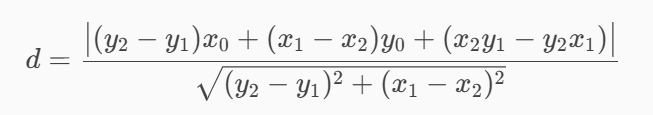

(x0​,y0​): the candidate point (k, inertia)

(x1,y1): first point on the curve (usually k=1)

(x2,y2): last point on the curve (largest k)

Compute d for each point and pick the one with maximum distance → that’s your elbow.

In [ ]:
# Programmatic elbow detection: distance-to-line ("kneedle"-like) heuristic
x1, y1 = k_values[0], inertias[0]
x2, y2 = k_values[-1], inertias[-1]
a = y2 - y1
b = x1 - x2
c = x2*y1 - y2*x1
distances = [abs(a*x0 + b*y0 + c) / np.sqrt(a**2 + b**2) for x0, y0 in zip(k_values, inertias)]
k_opt = k_values[int(np.argmax(distances))]
print(f"Suggested optimal number of clusters (elbow): k = {k_opt}")

Suggested optimal number of clusters (elbow): k = 4


## PCA plot

Think of PC1 and PC2 as data‑driven axes that compress the most important variation. Clusters positioned differently along these axes reflect distinct applicant profiles.

In [ ]:
# 5) PCA (2D) for visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_transformed)
print("Explained variance ratio (PC1, PC2):", np.round(pca.explained_variance_ratio_, 3))

Explained variance ratio (PC1, PC2): [0.132 0.116]


In [ ]:
# 6) Fit KMeans with k_opt and visualize
km_final = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=10)
km_labels = km_final.fit_predict(X_transformed)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap="tab10", s=35, edgecolor="k", alpha=0.8)
plt.title(f"KMeans Clusters (k={k_opt}) – PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

## Optional: Hierarchical clustering

Hierarchical clustering (Agglomerative, Ward linkage) with the same k_opt. Ward minimizes the sum of squared differences within all clusters. It is a variance-minimizing approach and in this sense is similar to the k-means objective function but tackled with an agglomerative hierarchical approach.



In [ ]:
# 7) Hierarchical clustering (Agglomerative, Ward linkage) with same k
#    Ward favors minimizing variance; works with Euclidean on numeric (and one-hot) features.
agg = AgglomerativeClustering(n_clusters=k_opt, linkage="ward")
agg_labels = agg.fit_predict(X_transformed)

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap="tab10", s=35, edgecolor="k", alpha=0.8)
plt.title(f"Agglomerative (Ward) Clusters (k={k_opt}) – PCA projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.25)
plt.show()

**Profiling = labeling**
* Numeric means (e.g., credit_amount, duration, age, existing_credits) say whether a segment is high/low risk exposure, short/long-term, etc.
* Categorical proportions (e.g., checking_status, savings_status, employment, housing) tell you which customer attributes dominate each segment—great for product tiering, risk policies, or marketing targeting.

In [ ]:
# 8) Cluster profiling
# Numeric: mean per cluster (original scale)
num_df = X_df[numeric_features].copy()
num_df["Cluster"] = km_labels
num_profile = num_df.groupby("Cluster").mean().round(2)
print("\nNumeric feature means by cluster (KMeans):")
print(num_profile)

# Categorical: proportions per cluster (top categories displayed)
cat_profile = {}
if len(categorical_features) > 0:
    cat_df = X_df[categorical_features].copy()
    cat_df["Cluster"] = km_labels
    for col in categorical_features:
        # normalized value counts per cluster
        vc = (
            cat_df.groupby("Cluster")[col]
            .value_counts(normalize=True)
            .rename("proportion")
            .reset_index()
        )
        # Keep top categories per cluster for readability
        cat_profile[col] = vc.sort_values(["Cluster", "proportion"], ascending=[True, False])

    print("\nCategorical proportions by cluster (KMeans) – top categories:")
    for col, table in cat_profile.items():
        print(f"\n{col}:")
        # Show only top 3 categories per cluster
        for cl in sorted(table["Cluster"].unique()):
            top3 = table[table["Cluster"] == cl].head(3)
            print(top3.to_string(index=False))

**segmentation ≠ decision**. Clusters should be used as exploratory insights, not automated credit decisions, and always with fairness and regulatory compliance in mind. If this is difficult to interpret for you, you can use AI to get a summary.

In [ ]:
# 9) Silhouette (quick quality sanity check)
sil_km = silhouette_score(X_transformed, km_labels)
sil_agg = silhouette_score(X_transformed, agg_labels)
print(f"\nSilhouette score (KMeans, k={k_opt}): {sil_km:.3f}")
print(f"Silhouette score (Agglomerative, k={k_opt}): {sil_agg:.3f}")



Silhouette score (KMeans, k=4): 0.098
Silhouette score (Agglomerative, k=4): 0.089


## Take home message

The elbow focuses on within‑cluster variance (KMeans inertia). The silhouette adds between‑cluster separation. Use both criteria, especially if the elbow is hard to pinpoint.

## Exercise:
Try different numbers of clusters (or different linkage/distance choices) and pick the one with the highest average silhouette—subject to business interpretability.
Diagnostics: Look at per‑cluster and per‑sample silhouettes to find clusters that are too diffuse, overlapping, or very small, and to spot suspect points near boundaries.